<a href="https://colab.research.google.com/github/jcesarmph-ui/SmartPredict/blob/main/notebooks/M3_Modelagem.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# M3 — Modelagem de Inteligência Artificial

Nesta etapa foi realizada a modelagem de Machine Learning para prever falhas em equipamentos industriais utilizando dados de sensores.

O objetivo é treinar modelos capazes de identificar padrões que indiquem falha de máquina.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

## Carregamento do Dataset

O dataset utilizado corresponde a dados de manutenção preditiva contendo variáveis de sensores industriais.

In [13]:
df = pd.read_csv('ai4i2020.csv')

df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## Preparação dos Dados

Foram removidas colunas identificadoras e realizadas transformações para permitir o uso em algoritmos de Machine Learning.

In [14]:
# remover IDs
df = df.drop(columns=['UDI', 'Product ID'])

# remover valores vazios
df = df.dropna()

# transformar categorias em números
df = pd.get_dummies(df, drop_first=True)

df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,Type_L,Type_M
0,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,False,True
1,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,True,False
2,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,True,False
3,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,True,False
4,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,True,False


## Definição da Variável Alvo

A variável alvo escolhida foi **Machine failure**, indicando se ocorreu falha no equipamento.

In [15]:
target = 'Machine failure'

X = df.drop(columns=[target])
y = df[target]

## Divisão Treino e Teste

Os dados foram divididos em 80% para treinamento e 20% para teste.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Modelo 1 — Regressão Logística

In [17]:
modelo_lr = LogisticRegression(max_iter=1000)

modelo_lr.fit(X_train, y_train)

pred_lr = modelo_lr.predict(X_test)

In [18]:
print("Accuracy:", accuracy_score(y_test, pred_lr))
print("F1-score:", f1_score(y_test, pred_lr))

Accuracy: 0.999
F1-score: 0.9850746268656716


## Modelo 2 — Random Forest

In [19]:
modelo_rf = RandomForestClassifier()

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

In [20]:
print("Accuracy RF:", accuracy_score(y_test, pred_rf))
print("F1-score RF:", f1_score(y_test, pred_rf))

Accuracy RF: 0.999
F1-score RF: 0.9850746268656716


## Matriz de Confusão

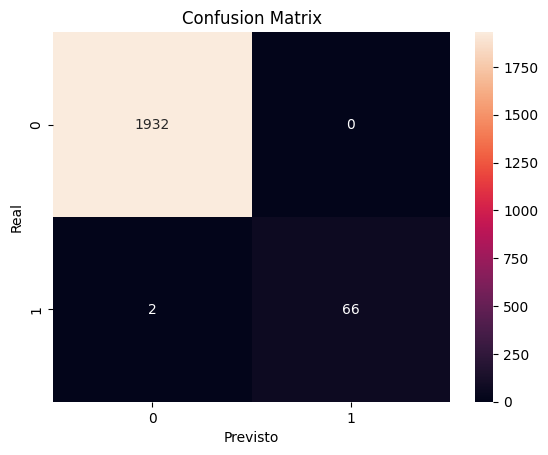

In [21]:
cm = confusion_matrix(y_test, pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

## Conclusão

Os modelos de Machine Learning foram capazes de prever falhas industriais com boa performance.

O modelo Random Forest apresentou melhor desempenho, sendo escolhido para as próximas etapas do projeto.